In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
zoo = pd.read_csv("/content/sample_data/zoo-data.csv")
class_type = pd.read_csv("/content/sample_data/zoo-class-type.csv")

print(zoo.head())
print(class_type.head())

  animal_name  hair  feathers  eggs  milk  airborne  aquatic  predator  \
0    aardvark     1         0     0     1         0        0         1   
1    antelope     1         0     0     1         0        0         0   
2        bass     0         0     1     0         0        1         1   
3        bear     1         0     0     1         0        0         1   
4        boar     1         0     0     1         0        0         1   

   toothed  backbone  breathes  venomous  fins  legs  tail  domestic  catsize  \
0        1         1         1         0     0     4     0         0        1   
1        1         1         1         0     0     4     1         0        1   
2        1         1         0         0     1     0     1         0        0   
3        1         1         1         0     0     4     0         0        1   
4        1         1         1         0     0     4     1         0        1   

   class_type  
0           1  
1           1  
2           4  
3   

In [4]:
zoo = zoo.drop("animal_name", axis=1)

In [5]:
X = zoo.drop("class_type", axis=1).values
y = zoo["class_type"].values

In [6]:
X = (X - X.mean(axis=0)) / X.std(axis=0)

In [7]:
indices = np.arange(len(X))
np.random.shuffle(indices)

X = X[indices]
y = y[indices]

split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]
y_train = y[:split]
y_test = y[split:]

In [8]:
X_train = np.c_[np.ones(X_train.shape[0]), X_train]
X_test = np.c_[np.ones(X_test.shape[0]), X_test]

In [9]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [10]:
classes = np.unique(y_train)
num_classes = len(classes)

In [11]:
weights = np.zeros((num_classes, X_train.shape[1]))

learning_rate = 0.01
epochs = 2000

In [12]:
for i, c in enumerate(classes):

    # Convert multiclass to binary (One-vs-Rest)
    y_binary = np.where(y_train == c, 1, 0)

    w = np.zeros(X_train.shape[1])

    for _ in range(epochs):
        z = np.dot(X_train, w)
        predictions = sigmoid(z)

        gradient = np.dot(X_train.T, (predictions - y_binary)) / len(y_binary)
        w -= learning_rate * gradient

    weights[i] = w

In [13]:
probabilities = []

for w in weights:
    z = np.dot(X_test, w)
    probabilities.append(sigmoid(z))

probabilities = np.array(probabilities)

# Choose class with highest probability
y_pred = classes[np.argmax(probabilities, axis=0)]

In [14]:
correct = 0
for i in range(len(y_test)):
    if y_test[i] == y_pred[i]:
        correct += 1

accuracy = correct / len(y_test)
print("Accuracy:", accuracy)

Accuracy: 0.9523809523809523


In [15]:
num_classes = len(classes)
conf_matrix = np.zeros((num_classes, num_classes))

for i in range(len(y_test)):
    true = int(y_test[i]) - 1
    pred = int(y_pred[i]) - 1
    conf_matrix[true][pred] += 1

print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[10.  0.  0.  0.  0.  0.  0.]
 [ 0.  4.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  3.  0.  0.  0.]
 [ 0.  0.  0.  0.  1.  0.  0.]
 [ 0.  0.  0.  0.  0.  1.  0.]
 [ 0.  0.  0.  0.  0.  1.  1.]]


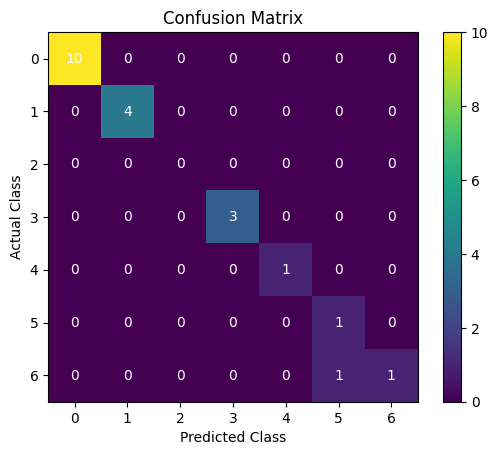

In [16]:
plt.imshow(conf_matrix)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.colorbar()

plt.xticks(range(num_classes))
plt.yticks(range(num_classes))

for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, int(conf_matrix[i, j]),
                 ha="center", va="center", color="white")

plt.show()